# PredictWell — Exploratory Data Analysis

This notebook explores the employee burnout dataset: distributions, correlations,
and the relationships between working conditions and burnout risk that motivate
the feature set used in `src/train.py`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/employee_burnout_data.csv")
df.shape

(3030, 13)

## 1. First look at the data

In [2]:
df.head()

,Age,Gender,Job_Role,Working_Hours_Per_Day,Number_of_Projects,Sleep_Hours,Work_Life_Balance_Score,Stress_Level,Overtime_Hours,Years_of_Experience,Satisfaction_Level,Remote_or_Onsite,Burnout_Risk
0,49,Male,Marketing Executive,8.7,1,6.2,9.4,1.0,0.7,6.4,10.0,Onsite,Low
1,47,Male,HR Specialist,10.0,4,6.9,7.0,1.9,2.4,17.0,7.4,Onsite,High
2,37,Female,Product Manager,6.0,2,9.5,10.0,1.0,0.0,10.8,8.8,Hybrid,Low
3,39,Female,Designer,10.3,1,6.6,8.4,2.0,5.1,16.1,7.8,Onsite,Medium
4,48,Male,Sales Executive,6.5,2,6.3,10.0,1.0,0.0,19.6,10.0,Hybrid,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3030 non-null   int64  
 1   Gender                   3030 non-null   object 
 2   Job_Role                 3030 non-null   object 
 3   Working_Hours_Per_Day    3030 non-null   float64
 4   Number_of_Projects       3030 non-null   int64  
 5   Sleep_Hours              3013 non-null   float64
 6   Work_Life_Balance_Score  3009 non-null   float64
 7   Stress_Level             3030 non-null   float64
 8   Overtime_Hours           3030 non-null   float64
 9   Years_of_Experience      3030 non-null   float64
 10  Satisfaction_Level       3022 non-null   float64
 11  Remote_or_Onsite         3030 non-null   object 
 12  Burnout_Risk             3030 non-null   object 
dtypes: float64(7), int64(2), object(4)
memory usage: 307.9+ KB


In [4]:
df.describe()

,Age,Working_Hours_Per_Day,Number_of_Projects,Sleep_Hours,Work_Life_Balance_Score,Stress_Level,Overtime_Hours,Years_of_Experience,Satisfaction_Level
count,3030.000000,3030.000000,3030.000000,3013.000000,3009.000000,3030.000000,3030.000000,3030.000000,3022.000000
mean,40.044224,8.455479,3.085149,7.471523,8.359056,2.079175,2.559967,10.506733,9.088054
std,11.283409,1.824834,1.678130,1.262283,1.860413,1.568337,3.361738,7.643521,1.156422
min,21.000000,4.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,1.100000
25%,30.000000,7.200000,2.000000,6.700000,7.400000,1.000000,0.000000,4.300000,8.500000
50%,40.000000,8.400000,3.000000,7.600000,9.000000,1.200000,1.000000,9.000000,9.500000
75%,50.000000,9.700000,4.000000,8.400000,10.000000,2.800000,4.300000,15.300000,10.000000
max,59.000000,14.000000,10.000000,9.500000,10.000000,10.000000,21.500000,34.100000,10.000000


## 2. Data quality — missing values & duplicates

In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
Sleep_Hours                17
Work_Life_Balance_Score    21
Satisfaction_Level          8
dtype: int64

Duplicate rows: 30


## 3. Target class distribution

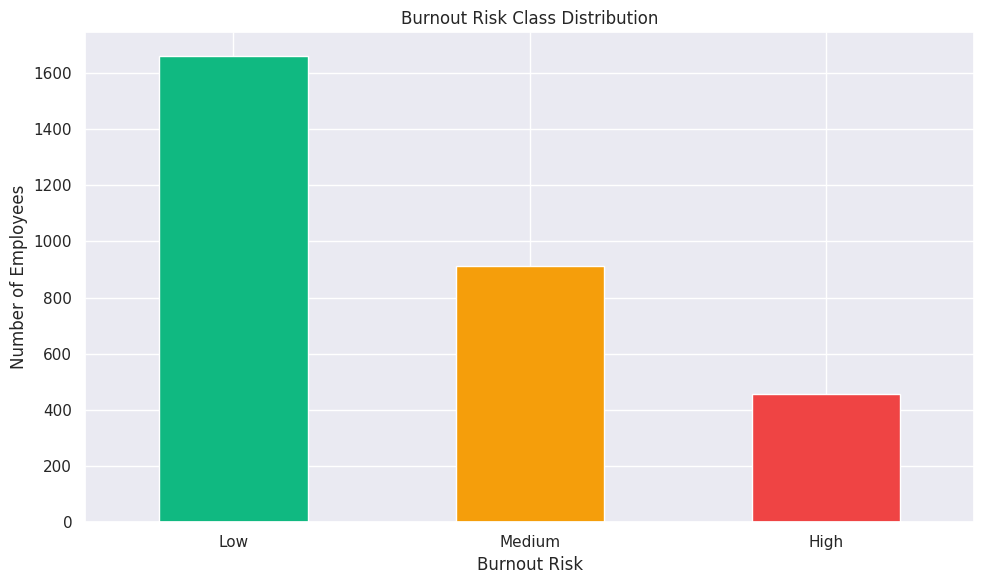

Burnout_Risk
Low       1661
Medium     912
High       457
Name: count, dtype: int64

In [6]:
order = ["Low", "Medium", "High"]
counts = df["Burnout_Risk"].value_counts().reindex(order)

ax = counts.plot(kind="bar", color=["#10B981", "#F59E0B", "#EF4444"])
ax.set_title("Burnout Risk Class Distribution")
ax.set_xlabel("Burnout Risk")
ax.set_ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

counts

## 4. Correlation heatmap (numeric features)

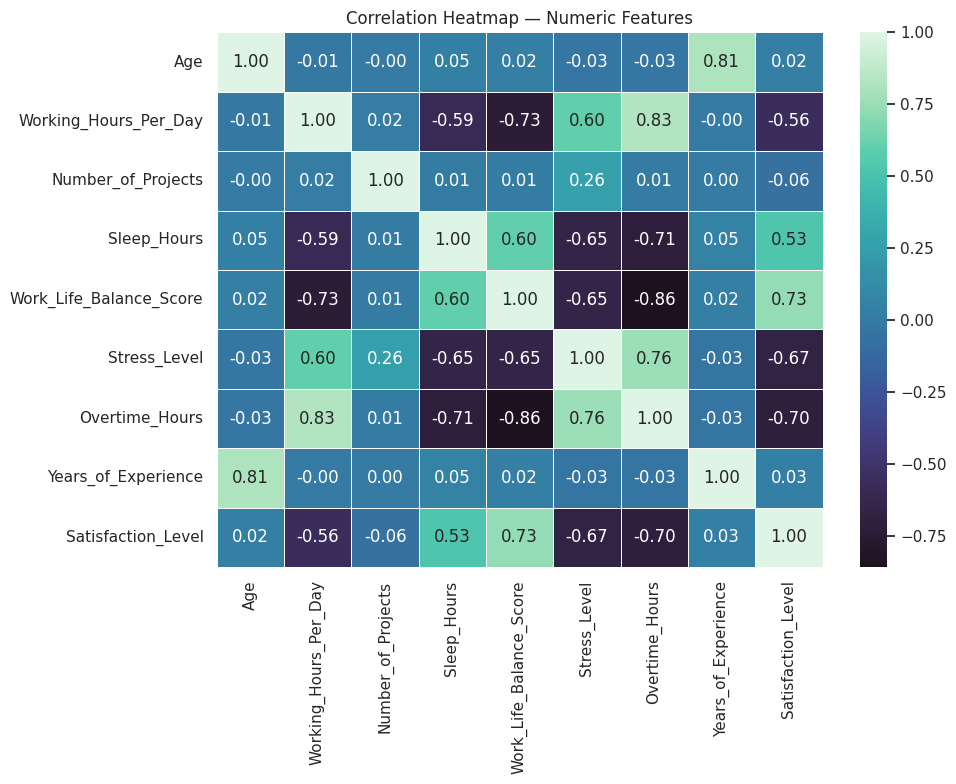

In [7]:
numeric_cols = [
    "Age", "Working_Hours_Per_Day", "Number_of_Projects", "Sleep_Hours",
    "Work_Life_Balance_Score", "Stress_Level", "Overtime_Hours",
    "Years_of_Experience", "Satisfaction_Level",
]

corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

## 5. Key relationships with burnout risk\n\nBoxplots of the strongest hypothesized burnout drivers, split by risk tier.

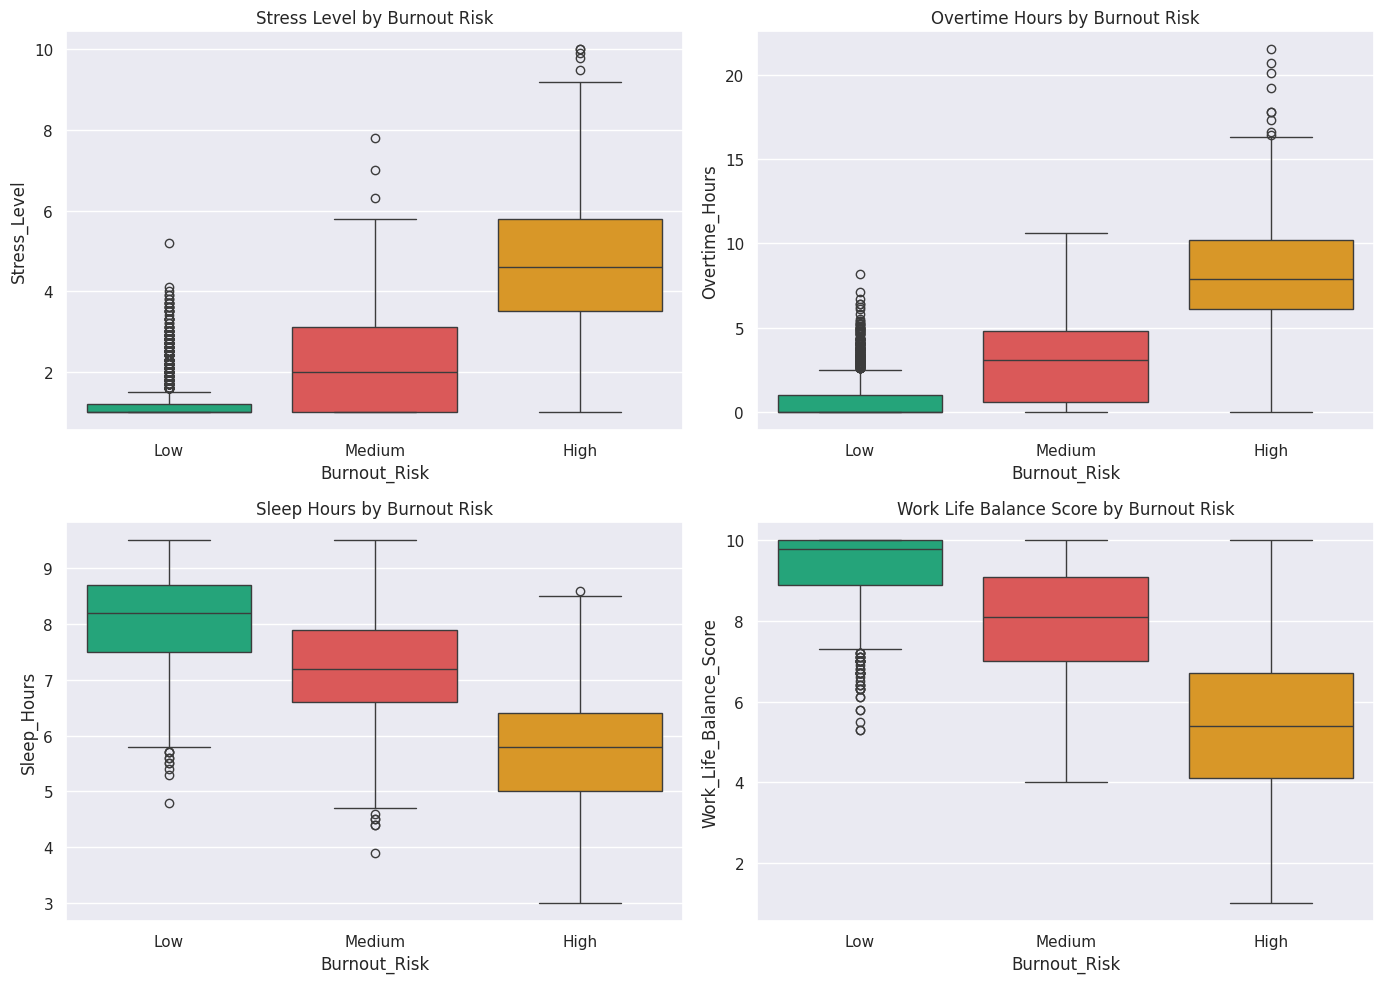

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [
    ("Stress_Level", axes[0, 0]),
    ("Overtime_Hours", axes[0, 1]),
    ("Sleep_Hours", axes[1, 0]),
    ("Work_Life_Balance_Score", axes[1, 1]),
]

for col, ax in pairs:
    sns.boxplot(data=df, x="Burnout_Risk", y=col, order=order, hue="Burnout_Risk",
                palette=["#10B981", "#F59E0B", "#EF4444"], legend=False, ax=ax)
    ax.set_title(f"{col.replace('_', ' ')} by Burnout Risk")

plt.tight_layout()
plt.show()

## 6. Burnout risk by job role

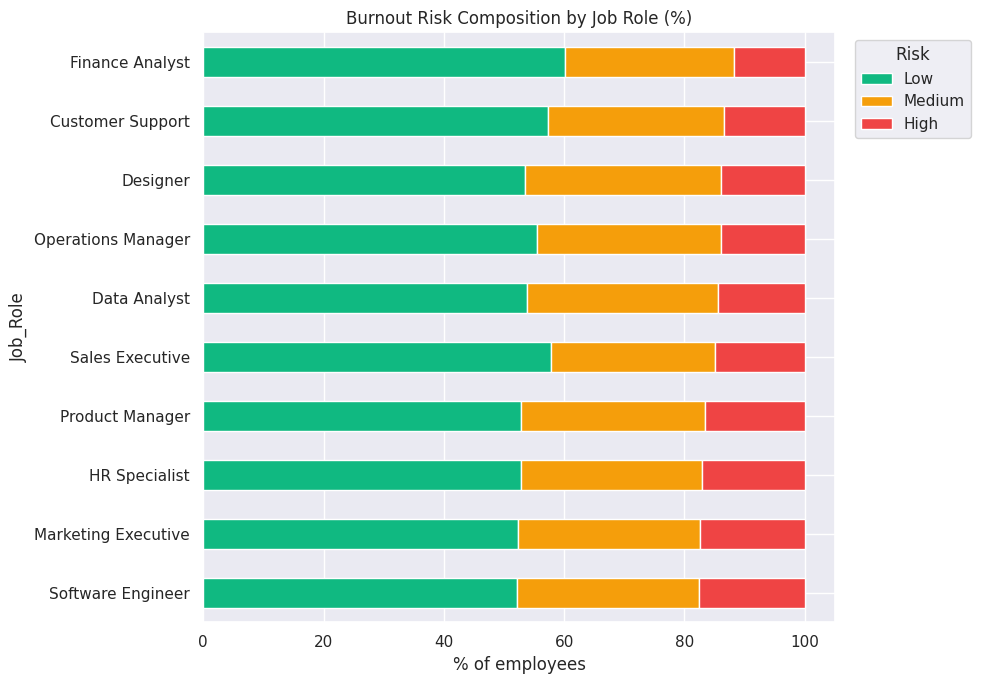

In [9]:
role_risk = pd.crosstab(df["Job_Role"], df["Burnout_Risk"], normalize="index")[order] * 100
role_risk.sort_values("High", ascending=False).plot(
    kind="barh", stacked=True, color=["#10B981", "#F59E0B", "#EF4444"], figsize=(10, 7)
)
plt.title("Burnout Risk Composition by Job Role (%)")
plt.xlabel("% of employees")
plt.legend(title="Risk", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Work mode (Remote / Onsite / Hybrid) vs. burnout

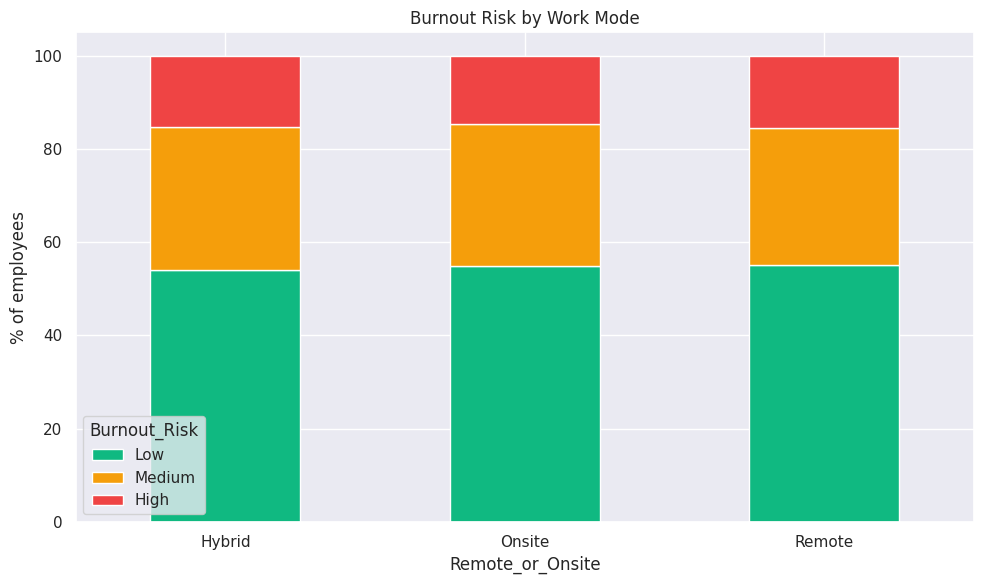

Burnout_Risk,Low,Medium,High
Remote_or_Onsite,,,
Hybrid,54.1,30.5,15.3
Onsite,55.0,30.4,14.6
Remote,55.2,29.4,15.4


In [10]:
mode_risk = pd.crosstab(df["Remote_or_Onsite"], df["Burnout_Risk"], normalize="index")[order] * 100
mode_risk.plot(kind="bar", stacked=True, color=["#10B981", "#F59E0B", "#EF4444"])
plt.title("Burnout Risk by Work Mode")
plt.ylabel("% of employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mode_risk.round(1)

## 8. Takeaways\n\n- **Stress level, overtime hours, sleep hours, and work-life balance score** show the clearest separation across burnout risk tiers — consistent with occupational health research.\n- The dataset is realistically **imbalanced** (~55% Low / 30% Medium / 15% High), so evaluation uses weighted precision/recall/F1 rather than raw accuracy alone.\n- These findings directly informed the feature set and the `Workload_Pressure` / `Rest_Deficit` engineered features used in `src/preprocess.py`.